### RANDOM FOREST CLASSIFIER MODELING

Models are built using Random Forest Classifier.

**Import libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.metrics import confusion_matrix, roc_curve
from sklearn.metrics import precision_recall_curve
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV, StratifiedKFold

**Load cleaned dataset**

In [ ]:
# Load the cleaned dataset
df = pd.read_csv('cleaned_data_ccf.csv')

In [ ]:
# Define X and y then split into train and test sets
X = df.drop(columns="is_fraud")
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
# Verify number of features

print(f'There are {len(X_train.columns)} features.')

There are 19 features.


In [ ]:
# Identify columns for preprocessing
cat_cols = X_train.select_dtypes(include="object").columns
num_cols = X_train.select_dtypes(exclude="object").columns

In [ ]:
# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(
            drop=None,
            handle_unknown='ignore'
        ), cat_cols),
    ],
    remainder='passthrough'
)

In [ ]:
# Build pipeline using class_weight
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(class_weight='balanced', random_state=42))
])
pipe.fit(X_train, y_train)
pipe

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['category', 'gender'], dtype='object'))])),
                ('rf',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [ ]:
# Define the hyperparameter grid
param_grid = {
    'rf__n_estimators': [200, 300],
    'rf__max_depth': [5, 8, 10],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [5, 10, 20]
}

In [ ]:
# Run GridSearchCV
grid = GridSearchCV(pipe, param_grid, cv=3, scoring="average_precision", n_jobs=-1, verbose=2)
grid.fit(X_train, y_train)

print(f'Best parameters: {grid.best_params_}')
print(f'Best score: {grid.best_score_:.4f}')

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best parameters: {'rf__max_depth': 10, 'rf__min_samples_leaf': 5, 'rf__min_samples_split': 2, 'rf__n_estimators': 300}
Best score: 0.6319


In [ ]:
# Obtain best parameters and score

print(f'Best parameters: {grid.best_params_}')
print(f'Best score: {grid.best_score_:.4f}')

Best parameters: {'rf__max_depth': 10, 'rf__min_samples_leaf': 5, 'rf__min_samples_split': 2, 'rf__n_estimators': 300}
Best score: 0.6319


In [ ]:
# Accuracy of model on train and test data
best_model = grid.best_estimator_

best_model_acc_train = best_model.score(X_train, y_train)
best_model_acc_test = best_model.score(X_test, y_test)

print(f'The train accuracy of the model is {best_model_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {best_model_acc_test*100:.2f}%')

The train accuracy of the model is 99.50%
The test accuracy of the model is 99.28%


In [ ]:
# Evaluate the best model
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("PR AUC:", average_precision_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5948
           1       0.58      0.65      0.61        52

    accuracy                           0.99      6000
   macro avg       0.79      0.82      0.80      6000
weighted avg       0.99      0.99      0.99      6000

ROC AUC: 0.9879759195075268
PR AUC: 0.6684451417398103


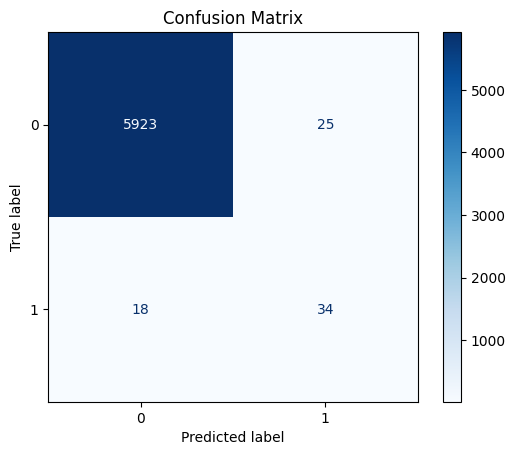

In [ ]:
# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=[0,1])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Values for false positive (fp), false negative (fn), true positive (tp) and true negative (tn)
fp = conf_matrix[0][1]
fn = conf_matrix[1][0]
tp = conf_matrix[1][1]
tn = conf_matrix[0][0]

print(f' fp: {fp} \n fn: {fn} \n tp: {tp} \n tn: {tn}')

 fp: 25 
 fn: 18 
 tp: 34 
 tn: 5923


In [ ]:
# Calculations for accuracy, precision, recall
accuracy = (tp + tn)/len(y_test)
precision = tp/(tp + fp)
recall = tp/(tp + fn)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')

Accuracy: 0.99
Precision: 0.58
Recall: 0.65


In [ ]:
# Calculate F2 score
beta = 2
F2_score = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall)

print(f'The F2 score is {F2_score:.4f}')

The F2 score is 0.6367


**Profit/Loss analysis**     
The profit/loss analysis compares the relative performance of the models financially. For demonstration purposes, the following values are used:     
**L** = value of fraud is \$800      
**C** = cost of preventive action is \$40     
True positives (**TP**) are correctly identified frauds (preventive action is spent but the value is saved).   
False positives (**FP**) are not fraudulent but predicted to be fraudulent (preventive action is spent but no value is saved).    
False negatives (**FN)** are predicted not to be fraudulent but actually fraudulent (no prevention action spent but value is lost).    
True negatives (**TN**) are correctly predicted not to be fraudulent (no prevention action spent and no value is lost).

In [ ]:
# Profit/loss analysis
L=800
C=40
Profit_Loss = tp*(L - C) - fp*C - fn*L

print(f'The profit or loss is ${Profit_Loss}')

The profit or loss is $10440


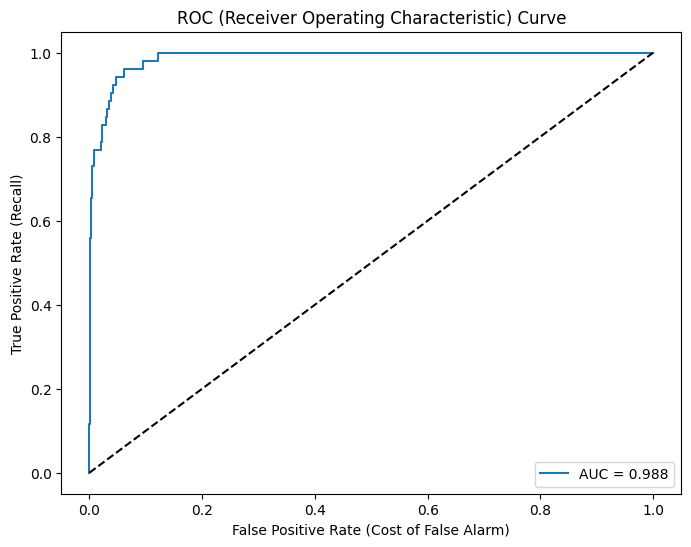

In [ ]:
# Plot the ROC Curve
y_proba = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = round(roc_auc_score(y_test, y_proba), 3)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba):.3f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [ ]:
# Find the optimal threshold from the ROC Curve that maximizes Youden's J
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold = thresholds[optimal_idx]

print(f'The optimal threshold is {optimal_threshold:.2f}')

The optimal threshold is 0.15


**Threshold that maximizes profit**    
The threshold that maximizes profit is obtained from the precision-recall curve.

In [ ]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

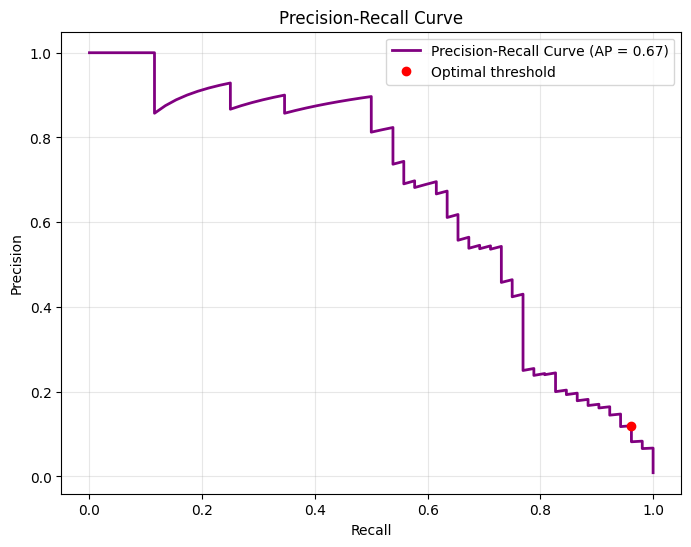

In [ ]:
# Plot the precision-recall curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.2f})', color='purple', lw=2)
# Mark the optimal threshold on the plot
idx = np.argmin(np.abs(thresholds-optimal_threshold))
plt.plot(recall[idx], precision[idx], 'ro', label='Optimal threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [ ]:
# Evaluate precision and recall at different thresholds
thresholds = np.arange(0.05, 0.30, 0.01)
for threshold in thresholds:
    preds = (y_proba >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.05 | Precision=0.04 | Recall=1.00
Threshold=0.06 | Precision=0.04 | Recall=1.00
Threshold=0.07 | Precision=0.05 | Recall=1.00
Threshold=0.08 | Precision=0.06 | Recall=1.00
Threshold=0.09 | Precision=0.07 | Recall=0.98
Threshold=0.10 | Precision=0.08 | Recall=0.98
Threshold=0.11 | Precision=0.08 | Recall=0.96
Threshold=0.12 | Precision=0.09 | Recall=0.96
Threshold=0.13 | Precision=0.10 | Recall=0.96
Threshold=0.14 | Precision=0.11 | Recall=0.96
Threshold=0.15 | Precision=0.12 | Recall=0.94
Threshold=0.16 | Precision=0.13 | Recall=0.94
Threshold=0.17 | Precision=0.14 | Recall=0.94
Threshold=0.18 | Precision=0.15 | Recall=0.94
Threshold=0.19 | Precision=0.16 | Recall=0.92
Threshold=0.20 | Precision=0.16 | Recall=0.92
Threshold=0.21 | Precision=0.17 | Recall=0.90
Threshold=0.22 | Precision=0.18 | Recall=0.88
Threshold=0.23 | Precision=0.18 | Recall=0.87
Threshold=0.24 | Precision=0.19 | Recall=0.87
Threshold=0.25 | Precision=0.20 | Recall=0.85
Threshold=0.26 | Precision=0.21 | 

In [ ]:
# Determine the threshold that maximizes profit
profits = []
for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    conf_matrix = confusion_matrix(y_test, y_pred)
    fp = conf_matrix[0][1]
    fn = conf_matrix[1][0]
    tp = conf_matrix[1][1]
    Profit_Loss = tp*(L - C) - fp*C - fn*L
    profits.append(Profit_Loss)

best_threshold = thresholds[np.argmax(profits)]

print(f'The threshold that maximizes profit is {best_threshold: .2f}')

The threshold that maximizes profit is  0.18


In [ ]:
# Use the threshold that maximizes profit
y_pred = (y_proba >= best_threshold).astype(int)

In [ ]:
# Generate classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98      5948
           1       0.15      0.94      0.25        52

    accuracy                           0.95      6000
   macro avg       0.57      0.95      0.61      6000
weighted avg       0.99      0.95      0.97      6000



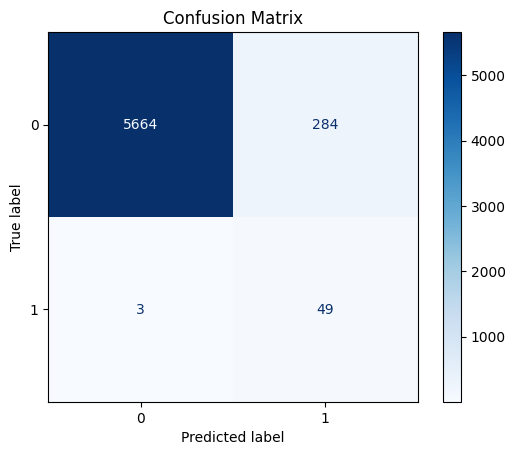

In [ ]:
# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=[0,1])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Values for false positive (fp), false negative (fn), true positive (tp) and true negative (tn)
fp = conf_matrix[0][1]
fn = conf_matrix[1][0]
tp = conf_matrix[1][1]
tn = conf_matrix[0][0]

print(f' fp: {fp} \n fn: {fn} \n tp: {tp} \n tn: {tn}')

 fp: 284 
 fn: 3 
 tp: 49 
 tn: 5664


In [ ]:
# Calculations for accuracy, precision, recall
accuracy = (tp + tn)/len(y_test)
precision = tp/(tp + fp)
recall = tp/(tp + fn)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')

Accuracy: 0.95
Precision: 0.15
Recall: 0.94


In [ ]:
# Calculate F2 score
beta = 2
F2_score = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall)

print(f'The F2 score is {F2_score:.4f}')

The F2 score is 0.4529


In [ ]:
# Profit/loss analysis
L=800
C=40
Profit_Loss = tp*(L - C) - fp*C - fn*L

print(f'The profit or loss is ${Profit_Loss}')

The profit or loss is $23480


**Feature Selection**    
SelectKBest tries to select the top features. However, as shown below, the number of features already provides the best AUC.

In [ ]:
# Get feature names after preprocessing
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

print(feature_names, '\n')
print(f'There are {len(feature_names)} feature names.')

['cat__category_entertainment' 'cat__category_food_dining'
 'cat__category_gas_transport' 'cat__category_grocery_net'
 'cat__category_grocery_pos' 'cat__category_health_fitness'
 'cat__category_home' 'cat__category_kids_pets' 'cat__category_misc_net'
 'cat__category_misc_pos' 'cat__category_personal_care'
 'cat__category_shopping_net' 'cat__category_shopping_pos'
 'cat__category_travel' 'cat__gender_F' 'cat__gender_M'
 'remainder__city_pop' 'remainder__zip_region' 'remainder__time_delta'
 'remainder__amt_vs_avg' 'remainder__dist_to_merch'
 'remainder__travel_speed' 'remainder__hour_sin' 'remainder__hour_cos'
 'remainder__dow_sin' 'remainder__dow_cos' 'remainder__is_night'
 'remainder__is_weekend' 'remainder__age' 'remainder__amt_log'
 'remainder__high_amt' 'remainder__merchant_freq'
 'remainder__missing_merch_zip'] 

There are 33 feature names.


In [ ]:
# Obtain the best number of features based on AUC
auc=[]
features = np.arange(27, 36, 3)
for i in features:
  # Set up selector
  selector1 = SelectKBest(
      score_func=mutual_info_classif,
      k=i
  )
  # Build pipeline using class_weight
  pipe1 = Pipeline([
      ('preprocessor', preprocessor),
      ('select', selector1),
      ('rf', RandomForestClassifier(class_weight='balanced', random_state=42))
  ])
  pipe1.fit(X_train, y_train)
  # Define parameter grid
  param_grid1 = {
      'rf__n_estimators': [200, 300],
      'rf__max_depth': [5, 8, 10],
      'rf__min_samples_split': [2, 5, 10],
      'rf__min_samples_leaf': [5, 10, 20]
  }
  # Run GridSearchCV
  grid1 = GridSearchCV(pipe, param_grid, cv=3, scoring="average_precision", n_jobs=-1, verbose=2)
  grid1.fit(X_train, y_train)
  # Access the optimized pipeline model
  best_model1 = grid1.best_estimator_
  # Evaluate 'roc_auc_score'
  y_proba1 = best_model1.predict_proba(X_test)[:, 1]
  roc_auc1 = roc_auc_score(y_test, y_proba1)
  auc.append(roc_auc1)
  print(f'Number of Features = {i} | AUC = {roc_auc1:.4f}')

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Number of Features = 27 | AUC = 0.9880
Fitting 3 folds for each of 54 candidates, totalling 162 fits
Number of Features = 30 | AUC = 0.9880
Fitting 3 folds for each of 54 candidates, totalling 162 fits
Number of Features = 33 | AUC = 0.9880


In [ ]:
# Determine best number of features and AUC
best_features = features[np.argmax(auc)]

print(f'The best number of features is {best_features}.')

The best number of features is 27.


In [ ]:
# Set up selector
selector = SelectKBest(
    score_func=mutual_info_classif,
    k=best_features
)

In [ ]:
# Build pipeline using class_weight
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('select', selector),
    ('rf', RandomForestClassifier(class_weight='balanced', random_state=42))
])
pipe.fit(X_train, y_train)
pipe

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['category', 'gender'], dtype='object'))])),
                ('select',
                 SelectKBest(k=np.int64(27),
                             score_func=<function mutual_info_classif at 0x78aa8ceef880>)),
                ('rf',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [ ]:
# Define parameter grid
param_grid = {
    'rf__n_estimators': [200, 300],
    'rf__max_depth': [5, 8, 10],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [5, 10, 20]
}

In [ ]:
# Run GridSearchCV
grid = GridSearchCV(pipe, param_grid, cv=3, scoring="average_precision", n_jobs=-1, verbose=2)
grid.fit(X_train, y_train)

print(f'Best parameters: {grid.best_params_}')
print(f'Best score: {grid.best_score_:.4f}')

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best parameters: {'rf__max_depth': 10, 'rf__min_samples_leaf': 5, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}
Best score: 0.6326


In [ ]:
# Access the optimized pipeline model
best_model = grid.best_estimator_

In [ ]:
# Accuracy on train and test data
best_model_acc_train = best_model.score(X_train, y_train)
best_model_acc_test = best_model.score(X_test, y_test)

print(f'The train accuracy of the model is {best_model_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {best_model_acc_test*100:.2f}%')

The train accuracy of the model is 99.45%
The test accuracy of the model is 99.15%


In [ ]:
# Generate classification report
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      5948
           1       0.51      0.63      0.56        52

    accuracy                           0.99      6000
   macro avg       0.75      0.81      0.78      6000
weighted avg       0.99      0.99      0.99      6000



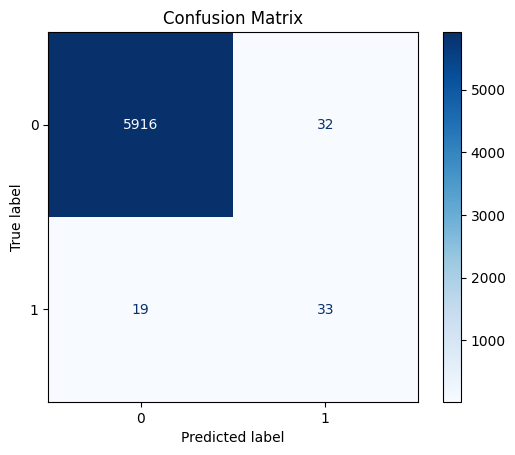

In [ ]:
# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=[0,1])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Values for false positive (fp), false negative (fn), true positive (tp) and true negative (tn)
fp = conf_matrix[0][1]
fn = conf_matrix[1][0]
tp = conf_matrix[1][1]
tn = conf_matrix[0][0]

print(f' fp: {fp} \n fn: {fn} \n tp: {tp} \n tn: {tn}')

 fp: 32 
 fn: 19 
 tp: 33 
 tn: 5916


In [ ]:
# Calculations for accuracy, precision, recall
accuracy = (tp + tn)/len(y_test)
precision = tp/(tp + fp)
recall = tp/(tp + fn)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')

Accuracy: 0.99
Precision: 0.51
Recall: 0.63


In [ ]:
# Calculate F2 score
beta = 2
F2_score = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall)

print(f'The F2 score is {F2_score:.4f}')

The F2 score is 0.6044


In [ ]:
# Profit/loss analysis
L=800
C=40
Profit_Loss = tp*(L - C) - fp*C - fn*L

print(f'The profit or loss is ${Profit_Loss}')

The profit or loss is $8600


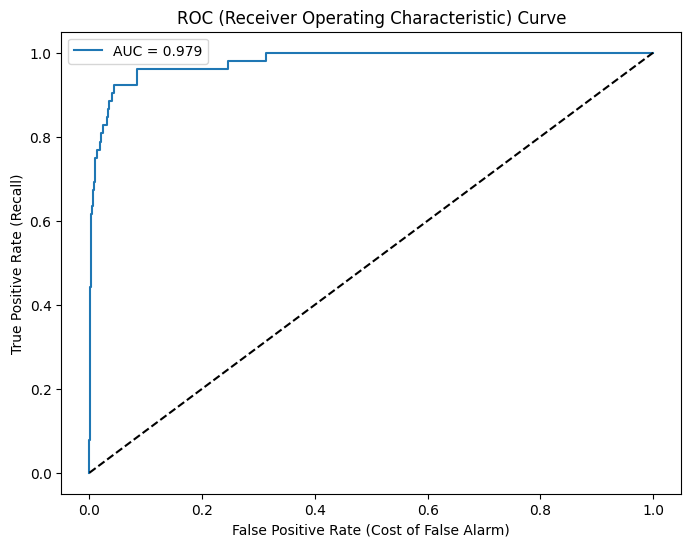

In [ ]:
# Plot the ROC Curve
y_proba = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = round(roc_auc_score(y_test, y_proba), 3)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba):.3f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [ ]:
# Find the optimal threshold from the ROC Curve that maximizes Youden's J
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold = thresholds[optimal_idx]

print(f'The optimal threshold is {optimal_threshold:.2f}')

The optimal threshold is 0.18


**Threshold that maximizes profit**    
The threshold that maximizes profit is obtained from the precision-recall curve.

In [ ]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

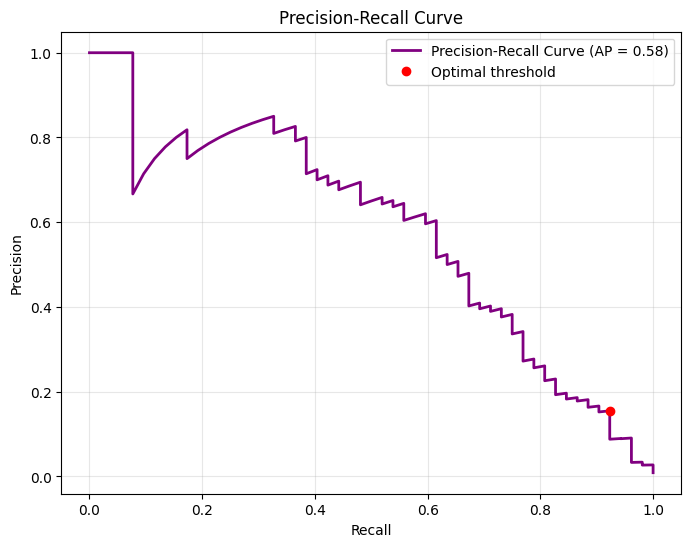

In [ ]:
# Plot the precision-recall curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.2f})', color='purple', lw=2)
# Mark the optimal threshold on the plot
idx = np.argmin(np.abs(thresholds-optimal_threshold))
plt.plot(recall[idx], precision[idx], 'ro', label='Optimal threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [ ]:
# Evaluate precision and recall at different thresholds
thresholds = np.arange(0, 0.30, 0.01)
for threshold in thresholds:
    preds = (y_proba >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.00 | Precision=0.01 | Recall=1.00
Threshold=0.01 | Precision=0.02 | Recall=1.00
Threshold=0.02 | Precision=0.02 | Recall=1.00
Threshold=0.03 | Precision=0.03 | Recall=0.98
Threshold=0.04 | Precision=0.03 | Recall=0.96
Threshold=0.05 | Precision=0.04 | Recall=0.96
Threshold=0.06 | Precision=0.05 | Recall=0.96
Threshold=0.07 | Precision=0.06 | Recall=0.96
Threshold=0.08 | Precision=0.07 | Recall=0.96
Threshold=0.09 | Precision=0.08 | Recall=0.96
Threshold=0.10 | Precision=0.09 | Recall=0.92
Threshold=0.11 | Precision=0.10 | Recall=0.92
Threshold=0.12 | Precision=0.11 | Recall=0.92
Threshold=0.13 | Precision=0.12 | Recall=0.92
Threshold=0.14 | Precision=0.12 | Recall=0.92
Threshold=0.15 | Precision=0.13 | Recall=0.92
Threshold=0.16 | Precision=0.14 | Recall=0.92
Threshold=0.17 | Precision=0.15 | Recall=0.92
Threshold=0.18 | Precision=0.16 | Recall=0.90
Threshold=0.19 | Precision=0.16 | Recall=0.90
Threshold=0.20 | Precision=0.17 | Recall=0.88
Threshold=0.21 | Precision=0.18 | 

In [ ]:
# Determine the threshold that maximizes profit
profits = []
for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    conf_matrix = confusion_matrix(y_test, y_pred)
    fp = conf_matrix[0][1]
    fn = conf_matrix[1][0]
    tp = conf_matrix[1][1]
    Profit_Loss = tp*(L - C) - fp*C - fn*L
    profits.append(Profit_Loss)

best_threshold = thresholds[np.argmax(profits)]

print(f'The threshold that maximizes profit is {best_threshold: .2f}')

The threshold that maximizes profit is  0.17


In [ ]:
# Use the threshold that maximizes profit
y_pred = (y_proba >= best_threshold).astype(int)

In [ ]:
# Generate classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98      5948
           1       0.15      0.92      0.26        52

    accuracy                           0.95      6000
   macro avg       0.57      0.94      0.62      6000
weighted avg       0.99      0.95      0.97      6000



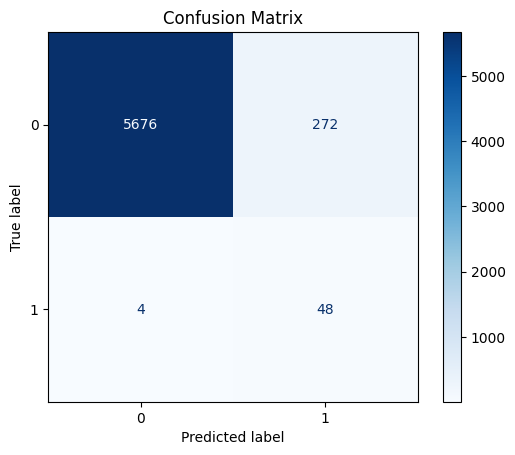

In [ ]:
# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=[0,1])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Values for false positive (fp), false negative (fn), true positive (tp) and true negative (tn)
fp = conf_matrix[0][1]
fn = conf_matrix[1][0]
tp = conf_matrix[1][1]
tn = conf_matrix[0][0]

print(f' fp: {fp} \n fn: {fn} \n tp: {tp} \n tn: {tn}')

 fp: 272 
 fn: 4 
 tp: 48 
 tn: 5676


In [ ]:
# Calculations for accuracy, precision, recall
accuracy = (tp + tn)/len(y_test)
precision = tp/(tp + fp)
recall = tp/(tp + fn)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')

Accuracy: 0.95
Precision: 0.15
Recall: 0.92


In [ ]:
# Calculate F2 score
beta = 2
F2_score = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall)

print(f'The F2 score is {F2_score:.4f}')

The F2 score is 0.4545


In [ ]:
# Profit/loss analysis
L=800
C=40
Profit_Loss = tp*(L - C) - fp*C - fn*L

print(f'The profit or loss is ${Profit_Loss}')

The profit or loss is $22400


**Feature Importance**


In [ ]:
# Access the selector
selector = best_model.named_steps["select"]

In [ ]:
# Get scores and selected features
scores = selector.scores_
mask = selector.get_support()
selected_features = feature_names[mask]
selected_features = [i.split('__')[-1] for i in selected_features]  # Clean feature names
selected_scores = scores[mask]

print(f'There are {len(selected_features)} selected features.')

There are 27 selected features.


In [ ]:
# Match features to scores
feature_importance_df = pd.DataFrame({
    'feature': selected_features,
    'importance': selected_scores
}).sort_values(by='importance', ascending=False)

In [ ]:
# Reset index
feature_importance_df = feature_importance_df.reset_index(drop=True)
feature_importance_df.index = feature_importance_df.index + 1
feature_importance_df.index.name = "Rank"

feature_importance_df.head(10)

,feature,importance
Rank,,
1,amt_log,0.023467
2,high_amt,0.015067
3,amt_vs_avg,0.011885
4,hour_cos,0.005869
5,city_pop,0.004124
6,gender_F,0.003517
7,hour_sin,0.003261
8,gender_M,0.002876
9,age,0.002368


In [ ]:
# Select the first twenty features
feature_importance_df = feature_importance_df.iloc[:20]

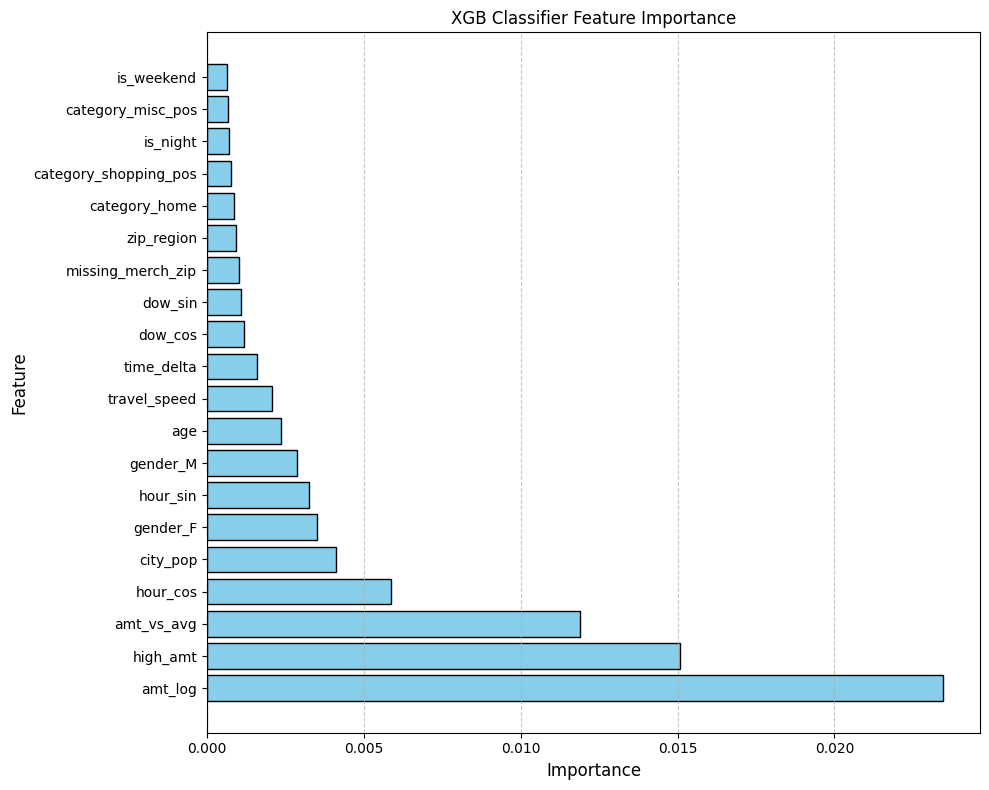

In [ ]:
# Plot the features and importance_means
plt.figure(figsize=(10, 8))
colors = ['salmon' if x < 0 else 'skyblue' for x in feature_importance_df['importance']]
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('XGB Classifier Feature Importance')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Model Summary**     

A dataframe is plotted to summarize the AUC, accuracy, precision, recall, F2 score and profit/loss.     

The final predictive model would need to consider the actual relative cost of missing a fraudulent transaction (false negatives - predicted not fraudulent but fraudulent) and false alarms (false positives - predicted fraudulent but actually not fraudulent) in order to determine the optimum mix of precision and recall.  

In [ ]:
# Build a dataframe
rf_model_df = pd.DataFrame({
    'Classifier': ['Random Forest'],
    'AUC': [auc],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F2 Score': [F2_score],
    'Profit/Loss': [Profit_Loss],
})
rf_model_df

,Classifier,AUC,Accuracy,Precision,Recall,F2 Score,Profit/Loss
0,Random Forest,0.979,0.954,0.15,0.923077,0.454545,22400


In [ ]:
# Output the XGBoost model performance metrics
rf_model_df.to_csv("rf_model.csv", index=False)

In [ ]:
# Output the XGBoost) features importance
feature_importance_df.to_csv("rf_features.csv", index=False)

**Sample Predictions**

In [ ]:
# List indices of fraudulent transactions
fraud_idx = y_test[y_test == 1].index

print(fraud_idx)

Index([26553,  5765,  6255,  4010,  3435,  7576, 29804, 18741,  2644,    81,
       12242, 18998, 27870, 13027, 24183, 25204,  7258, 17990,  9465, 13028,
         200, 16553, 24184, 23247, 22416, 10690, 12244,  2641,  9925,  7730,
       16352,   925, 22230,  2847,  1330, 24779, 10926, 16215,  8460, 28115,
       13059, 27688, 14839, 27600, 22415, 28114, 13324,  8461, 22229, 24480,
       15680, 20559],
      dtype='int64')


**Sample 1**

In [ ]:
# Obtain a sample from the test data
df_test1 = X_test.loc[26553]

print(df_test1, '\n')
print(f'Actual fraud status is {y_test.loc[26553]}')

category             shopping_pos
gender                          F
city_pop                   276002
zip_region                      3
time_delta              67.683333
amt_vs_avg               3.770236
dist_to_merch           16.125745
travel_speed            14.295169
hour_sin                -0.258819
hour_cos                 0.965926
dow_sin                  0.974928
dow_cos                 -0.222521
is_night                        0
is_weekend                      0
age                            69
amt_log                  6.852834
high_amt                        1
merchant_freq                  48
missing_merch_zip               0
Name: 26553, dtype: object 

Actual fraud status is 1


In [ ]:
# Transfer the data to a dictionary
sample1 = {
    "category": "shopping_pos",
    "gender": "F",
    "city_pop": 276002,
    "zip_region": 3,
    "time_delta": 67.683333,
    "amt_vs_avg": 3.770236,
    "dist_to_merch": 16.125745,
    "travel_speed": 14.295169,
    "hour_sin": -0.258819,
    "hour_cos": 0.965926,
    "dow_sin": 0.974928,
    "dow_cos": -0.222521,
    "is_night": 0,
    "is_weekend": 0,
    "age": 69,
    "amt_log": 6.852834,
    "high_amt": 1,
    "merchant_freq": 48,
    "missing_merch_zip": 0
}

In [ ]:
# Calculate fraud probability of the sample and provide fraud status of the sample
probability1 = best_model.predict_proba(pd.DataFrame([sample1]))[:, 1][0]

if probability1 >= best_threshold:
    print(f'The predicted fraud status is 1 \n')
else:
    print(f'The predicted fraud status is 0 \n')

print(f'The predicted fraud status probability is {probability1:.2f}')

The predicted fraud status is 1 

The predicted fraud status probability is 0.88


**Sample 2**

In [ ]:
# Obtain a sample from the test data
df_test2 = X_test.loc[5765]

print(df_test2, '\n')
print(f'Actual fraud status is {y_test.loc[5765]}')

category             grocery_pos
gender                         F
city_pop                     602
zip_region                     6
time_delta               3169.25
amt_vs_avg              3.997849
dist_to_merch          66.154038
travel_speed            1.252423
hour_sin                0.258819
hour_cos               -0.965926
dow_sin                -0.974928
dow_cos                -0.222521
is_night                       0
is_weekend                     1
age                           65
amt_log                 5.908871
high_amt                       1
merchant_freq                 58
missing_merch_zip              0
Name: 5765, dtype: object 

Actual fraud status is 1


In [ ]:
# Transfer the data to a dictionary
sample2 = {
    "category": "grocery_pos",
    "gender": "F",
    "city_pop": 602,
    "zip_region": 6,
    "time_delta": 3169.25,
    "amt_vs_avg": 3.997849,
    "dist_to_merch": 66.154038,
    "travel_speed": 1.252423,
    "hour_sin": 0.258819,
    "hour_cos": -0.965926,
    "dow_sin": -0.974928,
    "dow_cos": -0.222521,
    "is_night": 0,
    "is_weekend": 1,
    "age": 65,
    "amt_log": 5.908871,
    "high_amt": 1,
    "merchant_freq": 58,
    "missing_merch_zip": 0
}

In [ ]:
# Calculate fraud probability of the sample and provide fraud status of the sample
probability2 = best_model.predict_proba(pd.DataFrame([sample2]))[:, 1][0]

if probability2 >= best_threshold:
    print(f'The predicted fraud status is 1 \n')
else:
    print(f'The predicted fraud status is 0 \n')

print(f'The predicted fraud status probability is {probability2:.2f}')

The predicted fraud status is 1 

The predicted fraud status probability is 0.48


**Sample 3**

In [ ]:
# Obtain a sample from the test data
df_test3 = X_test.loc[200]

print(df_test3, '\n')
print(f'Actual fraud status is {y_test.loc[200]}')

category             grocery_pos
gender                         F
city_pop                    1439
zip_region                     9
time_delta                  -1.0
amt_vs_avg              0.947413
dist_to_merch          59.157745
travel_speed        -3549.464675
hour_sin                     0.5
hour_cos                0.866025
dow_sin                -0.781831
dow_cos                  0.62349
is_night                       1
is_weekend                     1
age                           20
amt_log                 5.601233
high_amt                       1
merchant_freq                 66
missing_merch_zip              0
Name: 200, dtype: object 

Actual fraud status is 1


In [ ]:
# Transfer the data to a dictionary
sample3 = {
    "category": "grocery_pos",
    "gender": "F",
    "city_pop": 1439,
    "zip_region": 9,
    "time_delta": -1.0,
    "amt_vs_avg": 0.947413,
    "dist_to_merch": 59.157745,
    "travel_speed": -3549.464675,
    "hour_sin": 0.5,
    "hour_cos": 0.866025,
    "dow_sin": -0.781831,
    "dow_cos": 0.62349,
    "is_night": 1,
    "is_weekend": 1,
    "age": 20,
    "amt_log": 5.601233,
    "high_amt": 1,
    "merchant_freq": 66,
    "missing_merch_zip": 0
}

In [ ]:
# Calculate fraud probability of the sample and provide fraud status of the sample
probability3 = best_model.predict_proba(pd.DataFrame([sample3]))[:, 1][0]

if probability3 >= best_threshold:
    print(f'The predicted fraud status is 1 \n')
else:
    print(f'The predicted fraud status is 0 \n')

print(f'The predicted fraud status probability is {probability3:.2f}')

The predicted fraud status is 1 

The predicted fraud status probability is 0.70


**Sample 4**

In [ ]:
# Obtain a sample from the test data
df_test4 = X_test.loc[10926]

print(df_test4, '\n')
print(f'Actual fraud status is {y_test.loc[10926]}')

category              grocery_pos
gender                          M
city_pop                  1241364
zip_region                      9
time_delta           10367.466667
amt_vs_avg               2.772653
dist_to_merch           39.560374
travel_speed             0.228949
hour_sin                 0.707107
hour_cos                 0.707107
dow_sin                       0.0
dow_cos                       1.0
is_night                        1
is_weekend                      0
age                            32
amt_log                  5.627585
high_amt                        1
merchant_freq                  63
missing_merch_zip               1
Name: 10926, dtype: object 

Actual fraud status is 1


In [ ]:
# Transfer the data to a dictionary
sample4 = {
    "category": "grocery_pos",
    "gender": "M",
    "city_pop": 1241364,
    "zip_region": 9,
    "time_delta": 10367.466667,
    "amt_vs_avg": 2.772653,
    "dist_to_merch": 39.560374,
    "travel_speed": 0.228949,
    "hour_sin": 0.707107,
    "hour_cos": 0.707107,
    "dow_sin": 0.0,
    "dow_cos": 1.0,
    "is_night": 1,
    "is_weekend": 0,
    "age": 32,
    "amt_log": 5.627585,
    "high_amt": 1,
    "merchant_freq": 63,
    "missing_merch_zip": 1
}

In [ ]:
# Calculate fraud probability of the sample and provide fraud status of the sample
probability4 = best_model.predict_proba(pd.DataFrame([sample4]))[:, 1][0]

if probability4 >= best_threshold:
    print(f'The predicted fraud status is 1 \n')
else:
    print(f'The predicted fraud status is 0 \n')

print(f'The predicted fraud status probability is {probability4:.2f}')

The predicted fraud status is 1 

The predicted fraud status probability is 0.61


**Sample 5**

In [ ]:
# Obtain a sample from the test data
df_test5 = X_test.loc[14839]

print(df_test5, '\n')
print(f'Actual fraud status is {y_test.loc[14839]}')

category             shopping_pos
gender                          F
city_pop                    31394
zip_region                      4
time_delta                 1146.7
amt_vs_avg              11.244951
dist_to_merch           46.099177
travel_speed             2.412096
hour_sin                -0.258819
hour_cos                 0.965926
dow_sin                       0.0
dow_cos                       1.0
is_night                        0
is_weekend                      0
age                            23
amt_log                  6.559049
high_amt                        1
merchant_freq                  58
missing_merch_zip               0
Name: 14839, dtype: object 

Actual fraud status is 1


In [ ]:
# Transfer the data to a dictionary
sample5 = {
    "category": "shopping_pos",
    "gender": "F",
    "city_pop": 31394,
    "zip_region": 4,
    "time_delta": 1146.7,
    "amt_vs_avg": 11.244951,
    "dist_to_merch": 46.099177,
    "travel_speed": 2.412096,
    "hour_sin": -0.258819,
    "hour_cos": 0.965926,
    "dow_sin": 0.0,
    "dow_cos": 1.0,
    "is_night": 0,
    "is_weekend": 0,
    "age": 23,
    "amt_log": 6.559049,
    "high_amt": 1,
    "merchant_freq": 58,
    "missing_merch_zip": 0
}

In [ ]:
# Calculate fraud probability of the sample and provide fraud status of the sample
probability5 = best_model.predict_proba(pd.DataFrame([sample5]))[:, 1][0]

if probability5 >= best_threshold:
    print(f'The predicted fraud status is 1 \n')
else:
    print(f'The predicted fraud status is 0 \n')

print(f'The predicted fraud status probability is {probability5:.2f}')

The predicted fraud status is 1 

The predicted fraud status probability is 0.87


**False Negatives** analysis

In [ ]:
# Get indexes of false negatives
false_negative_idx = y_test[(y_test == 1) & (y_pred == 0)].index
false_negative_idx

Index([81, 12244, 24779, 28115], dtype='int64')

In [ ]:
# See missed frauds rows
missed_frauds = X_test.loc[false_negative_idx]
missed_frauds.T

,81,12244,24779,28115
category,gas_transport,misc_pos,gas_transport,gas_transport
gender,M,F,M,M
city_pop,83,172247,1946,1656
zip_region,7,3,1,6
time_delta,1571.716667,352.866667,13119.316667,248.333333
amt_vs_avg,0.202453,0.090905,0.047319,0.225225
dist_to_merch,54.287751,48.052468,30.079873,45.427401
travel_speed,2.072425,8.170644,0.137568,10.975748
hour_sin,0.866025,0.965926,0.707107,0.707107
hour_cos,0.5,0.258819,0.707107,0.707107


In [ ]:
# Get actual and predicted
missed_frauds = X_test.loc[false_negative_idx].copy()
missed_frauds["actual"] = y_test.loc[false_negative_idx]

print(missed_frauds["actual"])

81       1
12244    1
24779    1
28115    1
Name: actual, dtype: int64


In [ ]:
# Convert numpy array to series
y_pred = pd.Series(y_pred.flatten(), index=X_test.index)
missed_frauds["predicted"] = y_pred.loc[false_negative_idx]

print(missed_frauds["predicted"])

81       0
12244    0
24779    0
28115    0
Name: predicted, dtype: int64
